In [ ]:
#Initializing Stuff
import sys
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import butter, filtfilt
from scipy.optimize import curve_fit
import pandas as pad
import tkinter as tk
from tkinter import filedialog
import os
sys.path.append( '/Users/Dell/Documents/RESEARCH/tmsi-python-interface-main/tmsi-python-interface-main/TMSiFileFormats/file_readers')
from poly5reader import Poly5Reader



In [1]:
#Initializing Stuff (If I am on my desktop)
import sys
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import butter, filtfilt
from scipy.optimize import curve_fit
import pandas as pad
import tkinter as tk
from tkinter import filedialog
import os
sys.path.append('/Users/Valie/Documents/Electrostim')
from poly5reader import Poly5Reader


In [2]:
#Get Data   
folder_path = "G:\\My Drive\\Research\\Data\\electrostim_data\\Doug 6-27\\20250627"
root =tk.Tk()
root.withdraw()  # Hide the root window
#select data (studying FLX only)
flexion_data = filedialog.askopenfilename(initialdir=folder_path, title="Select Flexion Data File")
#select baseline data (studying FLX only)
baseline_data = filedialog.askopenfilename(initialdir=folder_path, title="Select Baseline file")


In [3]:
accel_data_dict = {}

file_path = flexion_data
reader = Poly5Reader(file_path)
    #Extract Raw Samples (Channels x Samples)
samples = reader.samples
ch_names = reader.ch_names
sample_rate = reader.sample_rate
print(reader.ch_names)


trigger_channel = ['TRIGGERS']
trigger_indices = [ch_names.index(name) for name in trigger_channel if name in ch_names]
trigger_samples = samples [trigger_indices, :]
time_axis = np.arange(trigger_samples.shape[1])/ sample_rate


Reading file  G:/My Drive/Research/Data/electrostim_data/Doug 6-27/20250627/trial_7_FLX-20250627_152122.poly5
	 Number of samples:  123060 
	 Number of channels:  76 
	 Sample rate: 2000 Hz
Done reading data.
['CREF', 'R1C1', 'R1C2', 'R1C3', 'R1C4', 'R1C5', 'R1C6', 'R1C7', 'R1C8', 'R2C1', 'R2C2', 'R2C3', 'R2C4', 'R2C5', 'R2C6', 'R2C7', 'R2C8', 'R3C1', 'R3C2', 'R3C3', 'R3C4', 'R3C5', 'R3C6', 'R3C7', 'R3C8', 'R4C1', 'R4C2', 'R4C3', 'R4C4', 'R4C5', 'R4C6', 'R4C7', 'R4C8', 'R5C1', 'R5C2', 'R5C3', 'R5C4', 'R5C5', 'R5C6', 'R5C7', 'R5C8', 'R6C1', 'R6C2', 'R6C3', 'R6C4', 'R6C5', 'R6C6', 'R6C7', 'R6C8', 'R7C1', 'R7C2', 'R7C3', 'R7C4', 'R7C5', 'R7C6', 'R7C7', 'R7C8', 'R8C1', 'R8C2', 'R8C3', 'R8C4', 'R8C5', 'R8C6', 'R8C7', 'R8C8', 'BIP 01', 'BIP 02', 'BIP 03', 'BIP 04', 'ISO aux', 'ISO aux', 'AUX 1-3', 'AUX 2-1', 'TRIGGERS', 'STATUS', 'COUNTER']


In [ ]:
print(reader.ch_names[73])

In [4]:
trigger = samples[73,:]
emg = samples[1:65]

grid_order = [
    16, 15, 14, 13, 12, 8, 4, 0,  # Row 1 (17,16,15,14,13, 9, 5, 1)
    21, 20, 19, 18, 17, 9, 5, 1,  # Row 2 (22…2)
    26, 25, 24, 23, 22, 10, 6, 2,  # Row 3
    31, 30, 29, 28, 27, 11, 7, 3,  # Row 4
    32, 33, 34, 35, 36, 52, 56, 60,  # Row 5 (33…61)
    37, 38, 39, 40, 41, 53, 57, 61,  # Row 6
    42, 43, 44, 45, 46, 54, 58, 62,  # Row 7
    47, 48, 49, 50, 51, 55, 59, 63   # Row 8
]

<![alt text](image.png)>

Indexed starting at 0, so channel 30 = channel 31
Channel 17 = 1-1 = R1C1

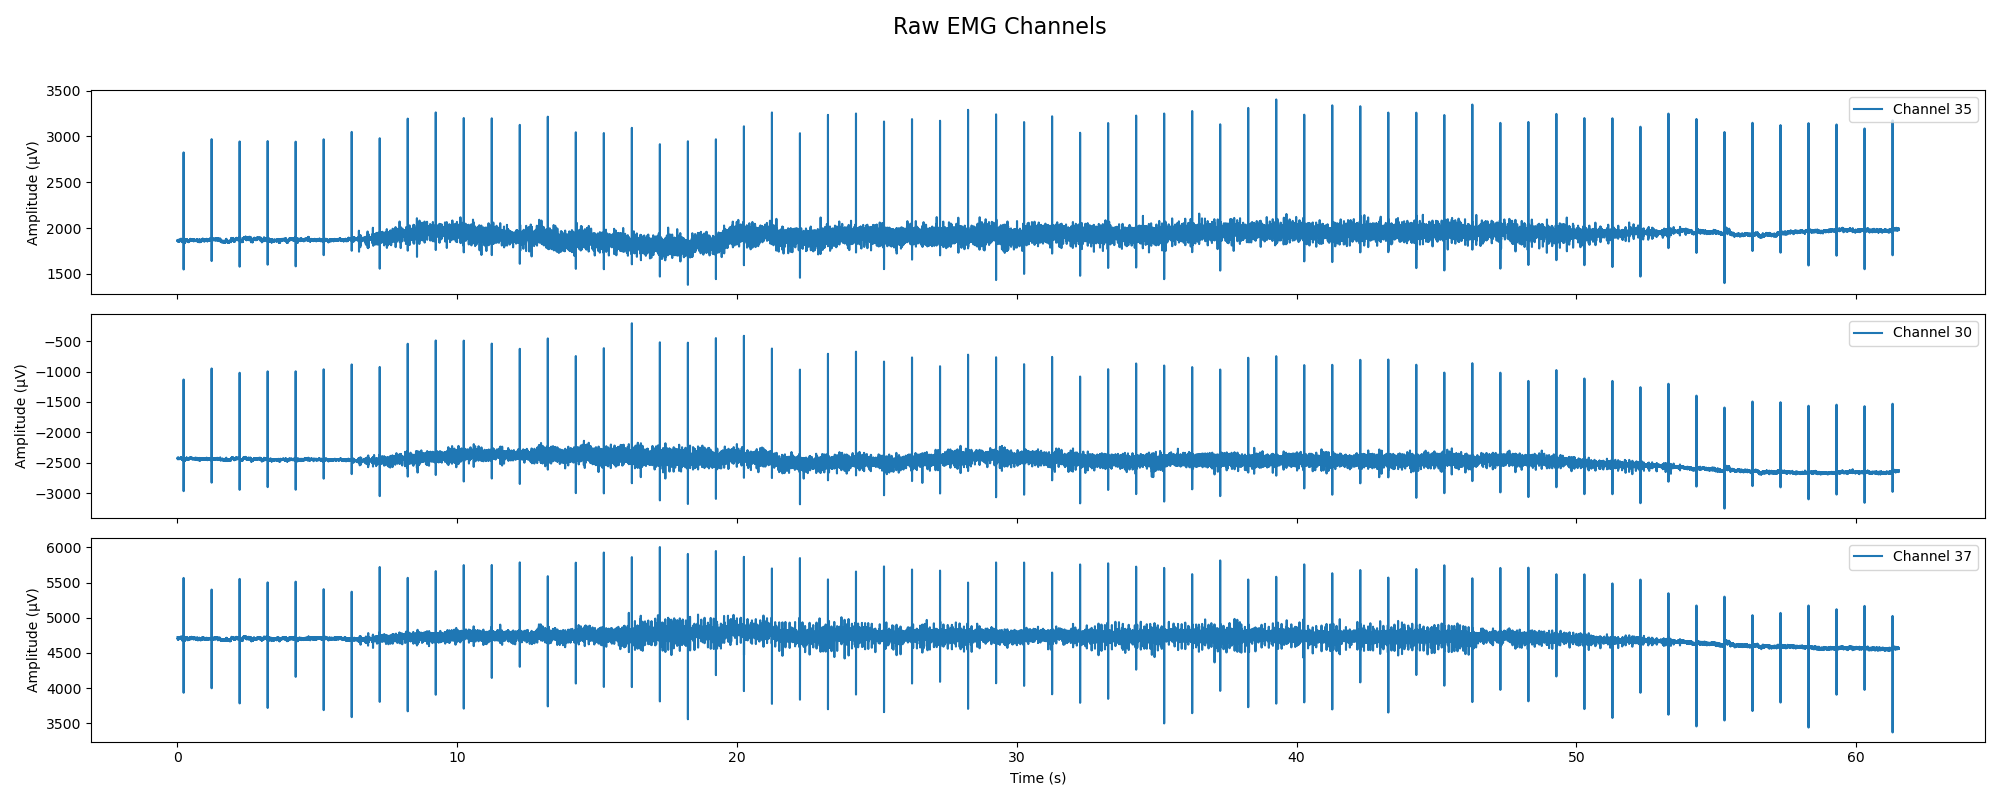

In [5]:
%matplotlib ipympl
#RAW EMG CHANNELS BEFORE FILTERINGddd

selected_channels = [35, 30, 37]  # Replace with the exact indices you want


# Number of selected channels
num_selected = len(selected_channels)


# Create subplots for each selected channel
fig, axes = plt.subplots(num_selected, 1, sharex=True, figsize=(20, 8))
plt.subplots_adjust(hspace=0.5)

# Loop over the selected channels and plot each one
for ax, ch_idx in zip(axes, selected_channels):
    ax.plot(time_axis, emg[ch_idx], label=f"Channel {ch_idx}")
    ax.set_ylabel("Amplitude (µV)")
    ax.legend(loc="upper right")

# Set common labels and title
axes[-1].set_xlabel("Time (s)")
fig.suptitle("Raw EMG Channels", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [6]:
#Smoothing/Bandpass Filtering
def bandpass_filter(x, lowcut, highcut, fs, order=4):
    nyq = fs/2
    b,a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, x)

def lpf_smooth(sig, cutoff, fs, order=5):
    nyq = fs/2
    b,a = butter(order, cutoff/nyq, btype='low')
    if sig.ndim==1:
        return filtfilt(b,a,sig)
    else:
        return np.vstack([filtfilt(b,a,chan) for chan in sig])

In [7]:
fs          = 2000.0        # sampling rate
lowcut      = 20.0          # band-pass low end (Hz)
highcut     = 450.0         # band-pass high end (Hz)
bp_order    = 4

lpf_cutoff  = 10.0          # envelope smoothing cutoff (Hz)
lpf_order   = 4

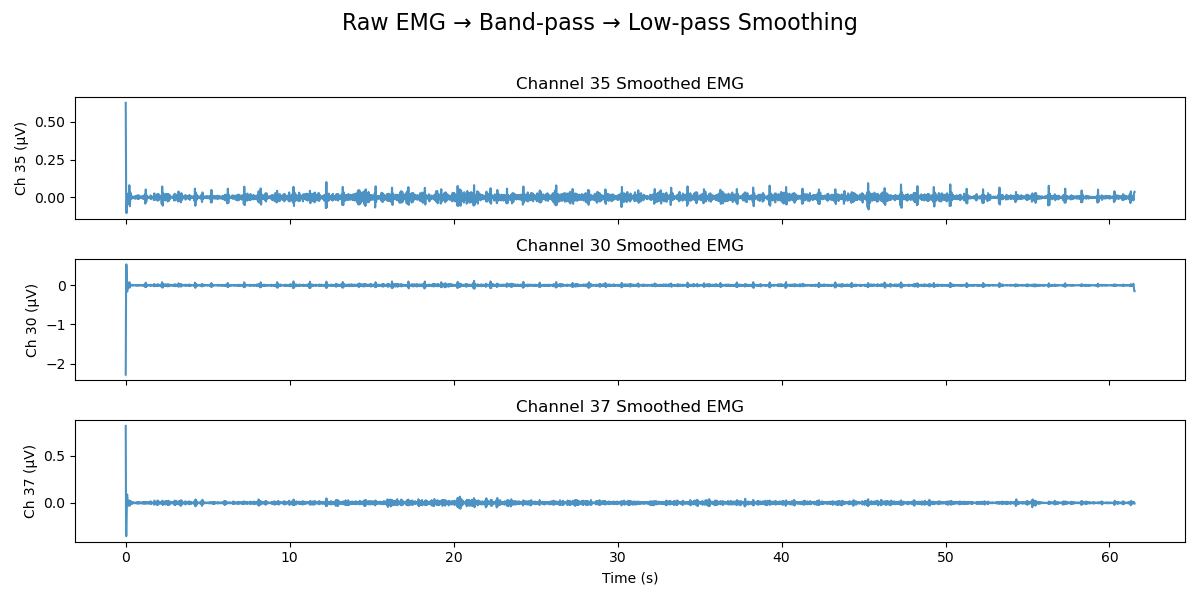

In [8]:

# === 1) BAND-PASS raw EMG ===
# emg: (n_channels, n_samples)


#selected_channels = [0, 30, 32] # Replace with the exact indices you want

filtered = np.zeros_like(emg)
for ch in range(emg.shape[0]):
    filtered[ch, :] = bandpass_filter(emg[ch, :],
                                       lowcut, highcut,
                                       fs, bp_order)

# === 2) LOW-PASS SMOOTH  *filtered* data ===
smoothed = lpf_smooth(filtered, lpf_cutoff, fs, lpf_order)

# === 3) PLOT the SMOOTHED EMG ===
fig, axes = plt.subplots(len(selected_channels), 1,
                         sharex=True, figsize=(12, 6))
plt.subplots_adjust(hspace=0.4)

for ax, ch in zip(axes, selected_channels):
    ax.plot(time_axis, smoothed[ch], color='C0', alpha=0.8)
    ax.set_ylabel(f"Ch {ch} (µV)")
    ax.set_title(f"Channel {ch} Smoothed EMG")

axes[-1].set_xlabel("Time (s)")
fig.suptitle("Raw EMG → Band-pass → Low-pass Smoothing", fontsize=16)
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

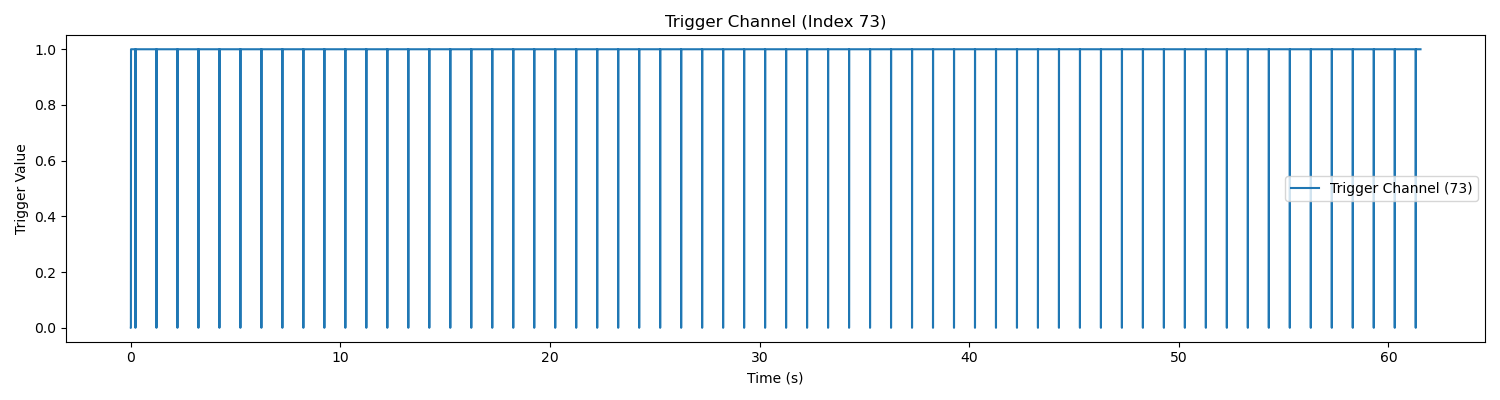

In [9]:
# Plot the trigger channel
plt.figure(figsize=(15, 4))
plt.plot(time_axis, trigger, label="Trigger Channel (73)")
plt.xlabel("Time (s)")
plt.ylabel("Trigger Value")
plt.title("Trigger Channel (Index 73)")
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
# Find falling edges: trigger goes from 1 to 0
falling_edges = np.where(np.diff(trigger) < -0.5)[0] + 1  # +1 to get the index after the transition

print("Indices where trigger goes from 1 to 0:", falling_edges)

# To get the time between each trigger (in seconds):
falling_times = time_axis[falling_edges]
intervals = np.diff(falling_times)
print("Time between each trigger (s):", intervals)

Indices where trigger goes from 1 to 0: [   437   2440   4442   6445   8448  10450  12453  14456  16458  18462
  20464  22467  24470  26472  28475  30478  32481  34483  36486  38489
  40491  42494  44497  46499  48502  50505  52508  54511  56513  58516
  60519  62522  64524  66527  68530  70532  72535  74538  76540  78543
  80546  82549  84552  86554  88557  90560  92563  94565  96568  98571
 100573 102576 104579 106581 108584 110587 112590 114593 116595 118598
 120601 122603]
Time between each trigger (s): [1.0015 1.001  1.0015 1.0015 1.001  1.0015 1.0015 1.001  1.002  1.001
 1.0015 1.0015 1.001  1.0015 1.0015 1.0015 1.001  1.0015 1.0015 1.001
 1.0015 1.0015 1.001  1.0015 1.0015 1.0015 1.0015 1.001  1.0015 1.0015
 1.0015 1.001  1.0015 1.0015 1.001  1.0015 1.0015 1.001  1.0015 1.0015
 1.0015 1.0015 1.001  1.0015 1.0015 1.0015 1.001  1.0015 1.0015 1.001
 1.0015 1.0015 1.001  1.0015 1.0015 1.0015 1.0015 1.001  1.0015 1.0015
 1.001 ]


In [ ]:
#First STA try
# Spike-Triggered Average (STA) using ±50 ms window 

# Parameters
window_ms = 50  # window before and after trigger in ms
window_samples = int(window_ms * sample_rate / 1000)  # samples per side
total_window = 2 * window_samples  # total window size (samples)

# Find trigger events (rising edges)
trigger_diff = np.diff(trigger)
trigger_onsets = np.where(trigger_diff > 0.5)[0] + 1  # adjust for diff offset

# Only keep triggers far enough from start/end for window
valid_triggers = trigger_onsets[
    (trigger_onsets > window_samples) & (trigger_onsets < trigger.shape[0] - window_samples)
]

# Extract EMG snippets around each trigger
snippets = []
for idx in valid_triggers:
    snippet = emg[:, idx - window_samples : idx + window_samples]
    snippets.append(snippet)
snippets = np.stack(snippets, axis=0)  # shape: (n_triggers, n_channels, window)

# Compute average across triggers
sta = np.mean(snippets, axis=0)  # shape: (n_channels, window)

# Time axis for window (centered at trigger)
sta_time = np.linspace(-window_ms, window_ms, total_window)

# Plot STA for selected channels
selected_channels = [0, 30, 32]
plt.figure(figsize=(12, 6))
for ch in selected_channels:
    plt.plot(sta_time, sta[ch], label=f'Ch {ch}')
plt.xlabel('Time (ms) relative to trigger')
plt.ylabel('EMG (µV)')
plt.title('Spike-Triggered Average (±50 ms window)')
plt.legend()
plt.tight_layout()
plt.show()

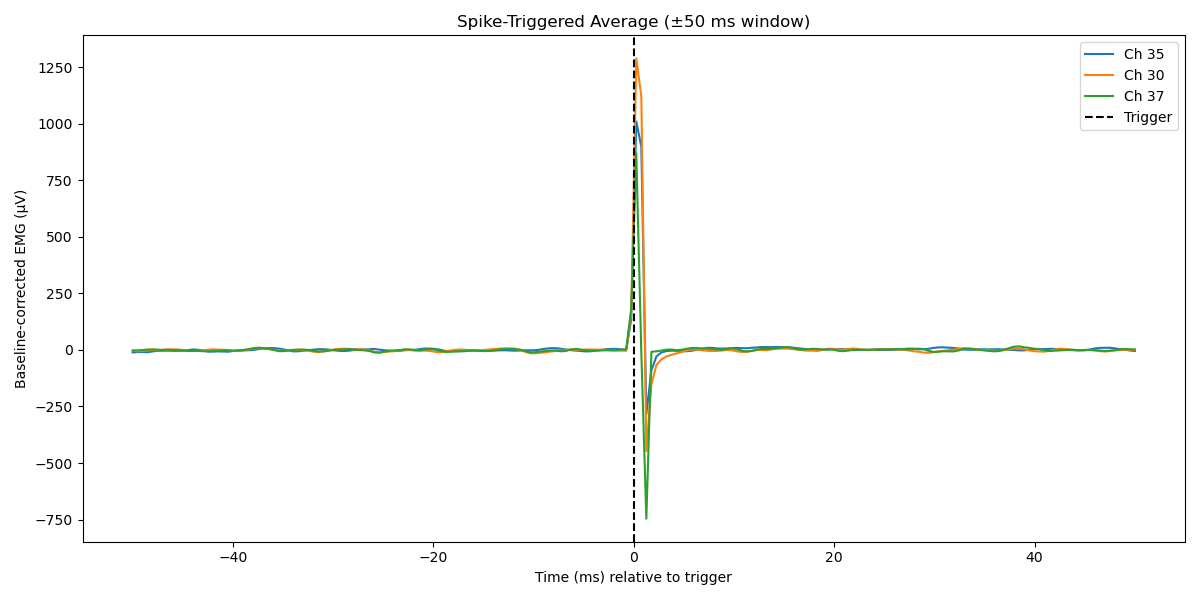

In [12]:
# Spike-Triggered Average (STA) with Baseline Correction (±50 ms window)


# Parameters
window_ms = 50  # window before and after trigger in ms
window_samples = int(window_ms * sample_rate / 1000)  # samples per side, /1000 to convert ms to samples
total_window = 2 * window_samples  # total window size (samples)

# Find trigger events (rising edges)
trigger_diff = np.diff(trigger)
trigger_onsets = np.where(trigger_diff > 0.5)[0] + 1  # adjust for diff offset

# Only keep triggers far enough from start/end for window
valid_triggers = trigger_onsets[
    (trigger_onsets > window_samples) & (trigger_onsets < trigger.shape[0] - window_samples)
]

# Extract and baseline-correct EMG snippets around each trigger
snippets = []
for idx in valid_triggers:
    # raw snippet: shape (n_channels, window)
    snippet = emg[:, idx - window_samples : idx + window_samples]
    # compute baseline from pre-spike portion (first window_samples)
    baseline = np.mean(snippet[:, :window_samples], axis=1, keepdims=True)
    # subtract baseline to center around zero
    snippet_corrected = snippet - baseline
    snippets.append(snippet_corrected)

snippets = np.stack(snippets, axis=0)  # shape: (n_triggers, n_channels, window)

# Compute average across baseline-corrected snippets
sta = np.mean(snippets, axis=0)  # shape: (n_channels, window)

# Time axis for window (centered at trigger)
sta_time = np.linspace(-window_ms, window_ms, total_window)

# Plot STA for selected channels
selected_channels = [35, 30, 37]
plt.figure(figsize=(12, 6))
for ch in selected_channels:
    plt.plot(sta_time, sta[ch], label=f'Ch {ch}')

plt.axvline(0, color='k', linestyle='--', label='Trigger')
plt.xlabel('Time (ms) relative to trigger')
plt.ylabel('Baseline-corrected EMG (µV)')
plt.title('Spike-Triggered Average (±50 ms window)')
plt.legend()
plt.tight_layout()
plt.show()


 ABOVE = M WAVE YAY?

In [13]:
# Compute peak-to-peak amplitude for each channel in the STA
# sta: shape (n_channels, window)

peak_to_peak = np.ptp(sta, axis=1)  # shape: (n_channels,)

# Example: print or plot for selected channels
for ch in selected_channels:
    print(f"Channel {ch}: Peak-to-peak amplitude = {peak_to_peak[ch]:.2f} µV")

Channel 35: Peak-to-peak amplitude = 1293.36 µV
Channel 30: Peak-to-peak amplitude = 1735.00 µV
Channel 37: Peak-to-peak amplitude = 1614.48 µV


In [41]:
# Get Data   
folder_path = "G:\\My Drive\\Research\\Data\\electrostim_data\\Doug 6-27\\20250627"
root = tk.Tk()
root.withdraw()  # Hide the root window

# Select multiple flexion data files
flexion_files = filedialog.askopenfilenames(
    initialdir=folder_path,
    title="Select Flexion Data Files"
)

# Select baseline data (single file)
baseline_data = filedialog.askopenfilename(
    initialdir=folder_path,
    title="Select Baseline file"
)

# flexion_files will be a tuple of file paths
print("Selected flexion files:", flexion_files)
print("Selected baseline file:", baseline_data)

Selected flexion files: ('G:/My Drive/Research/Data/electrostim_data/Doug 6-27/20250627/trial_6_FLX-20250627_151916.poly5', 'G:/My Drive/Research/Data/electrostim_data/Doug 6-27/20250627/trial_7_FLX-20250627_152122.poly5', 'G:/My Drive/Research/Data/electrostim_data/Doug 6-27/20250627/trial_8_FLX-20250627_152242.poly5', 'G:/My Drive/Research/Data/electrostim_data/Doug 6-27/20250627/trial_19_FLX-20250627_154228.poly5')
Selected baseline file: G:/My Drive/Research/Data/electrostim_data/Doug 6-27/20250627/trial_2_FLX-20250627_150914.poly5


In [42]:
# Loop through each selected flexion file
for file_path in flexion_files:
    reader = Poly5Reader(file_path)
    samples = reader.samples
    ch_names = reader.ch_names
    sample_rate = reader.sample_rate
    print(f"Loaded: {file_path}")
    print(reader.ch_names)

    # Extract trigger and EMG data
    trigger_channel = ['TRIGGERS']
    trigger_indices = [ch_names.index(name) for name in trigger_channel if name in ch_names]
    trigger_samples = samples[trigger_indices, :]
    time_axis = np.arange(trigger_samples.shape[1]) / sample_rate

    # Example: extract EMG channels (adjust indices as needed) and triggers
    emg = samples[1:65, :]
    trigger = samples[73,:]

    # processing emg, trigger_samples, etc. for each file

Reading file  G:/My Drive/Research/Data/electrostim_data/Doug 6-27/20250627/trial_6_FLX-20250627_151916.poly5
	 Number of samples:  122430 
	 Number of channels:  76 
	 Sample rate: 2000 Hz
Done reading data.
Loaded: G:/My Drive/Research/Data/electrostim_data/Doug 6-27/20250627/trial_6_FLX-20250627_151916.poly5
['CREF', 'R1C1', 'R1C2', 'R1C3', 'R1C4', 'R1C5', 'R1C6', 'R1C7', 'R1C8', 'R2C1', 'R2C2', 'R2C3', 'R2C4', 'R2C5', 'R2C6', 'R2C7', 'R2C8', 'R3C1', 'R3C2', 'R3C3', 'R3C4', 'R3C5', 'R3C6', 'R3C7', 'R3C8', 'R4C1', 'R4C2', 'R4C3', 'R4C4', 'R4C5', 'R4C6', 'R4C7', 'R4C8', 'R5C1', 'R5C2', 'R5C3', 'R5C4', 'R5C5', 'R5C6', 'R5C7', 'R5C8', 'R6C1', 'R6C2', 'R6C3', 'R6C4', 'R6C5', 'R6C6', 'R6C7', 'R6C8', 'R7C1', 'R7C2', 'R7C3', 'R7C4', 'R7C5', 'R7C6', 'R7C7', 'R7C8', 'R8C1', 'R8C2', 'R8C3', 'R8C4', 'R8C5', 'R8C6', 'R8C7', 'R8C8', 'BIP 01', 'BIP 02', 'BIP 03', 'BIP 04', 'ISO aux', 'ISO aux', 'AUX 1-3', 'AUX 2-1', 'TRIGGERS', 'STATUS', 'COUNTER']
Reading file  G:/My Drive/Research/Data/electrost

Reading file  G:/My Drive/Research/Data/electrostim_data/Doug 6-27/20250627/trial_6_FLX-20250627_151916.poly5
	 Number of samples:  122430 
	 Number of channels:  76 
	 Sample rate: 2000 Hz
Done reading data.


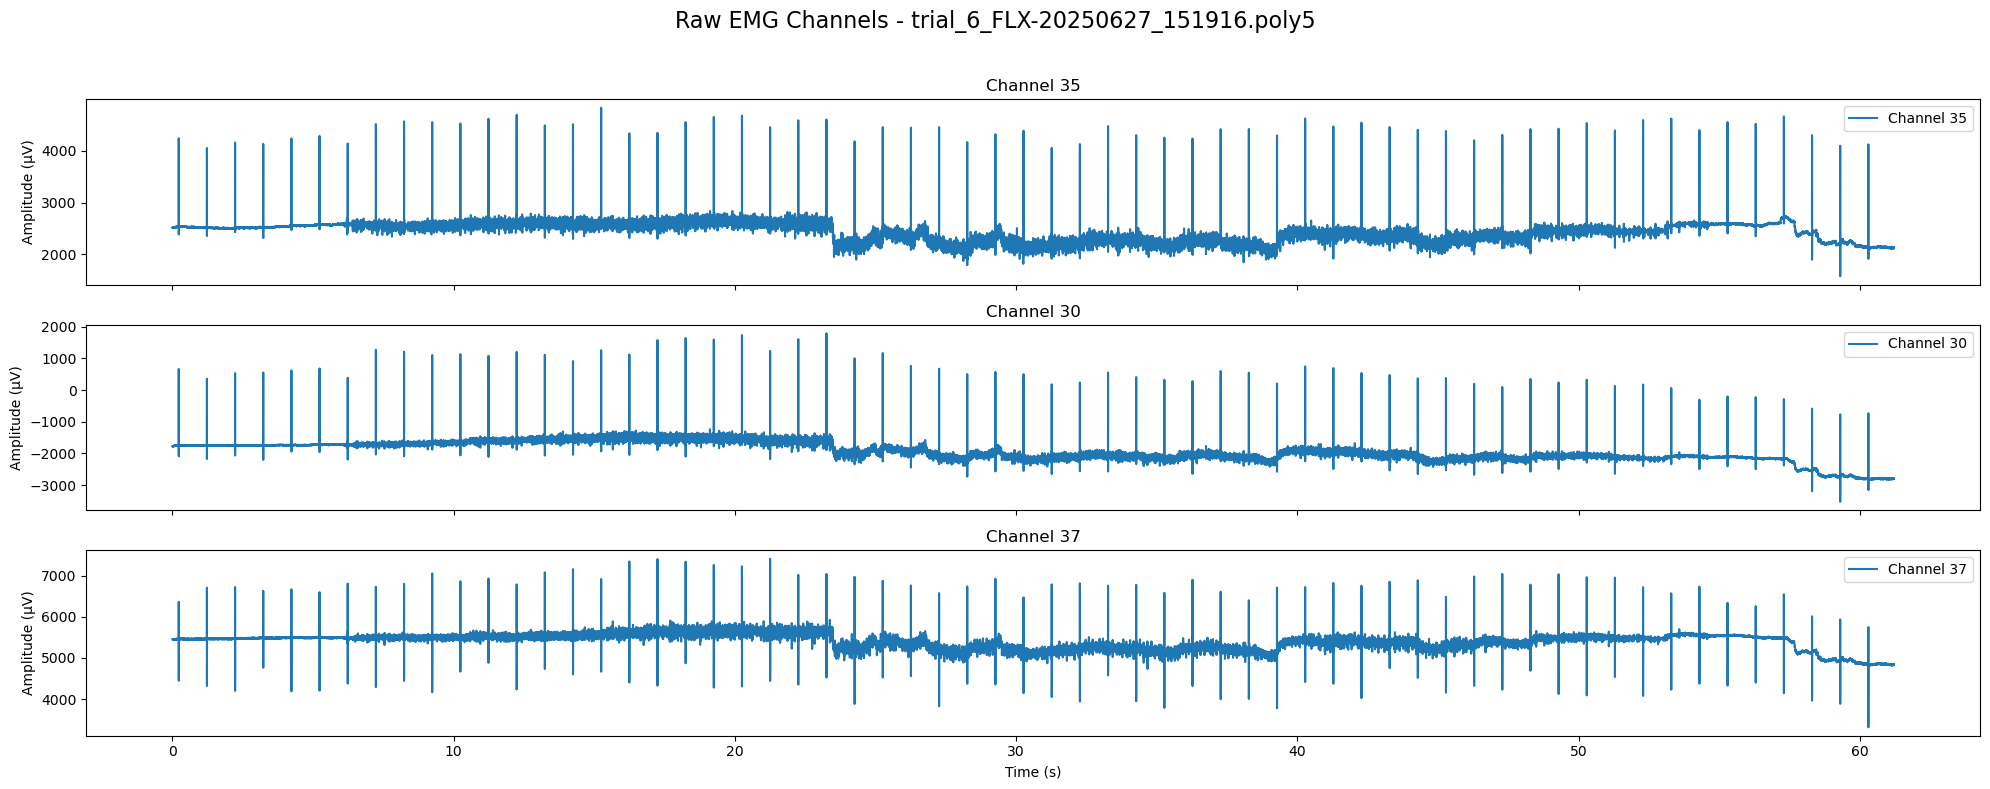

Reading file  G:/My Drive/Research/Data/electrostim_data/Doug 6-27/20250627/trial_7_FLX-20250627_152122.poly5
	 Number of samples:  123060 
	 Number of channels:  76 
	 Sample rate: 2000 Hz
Done reading data.


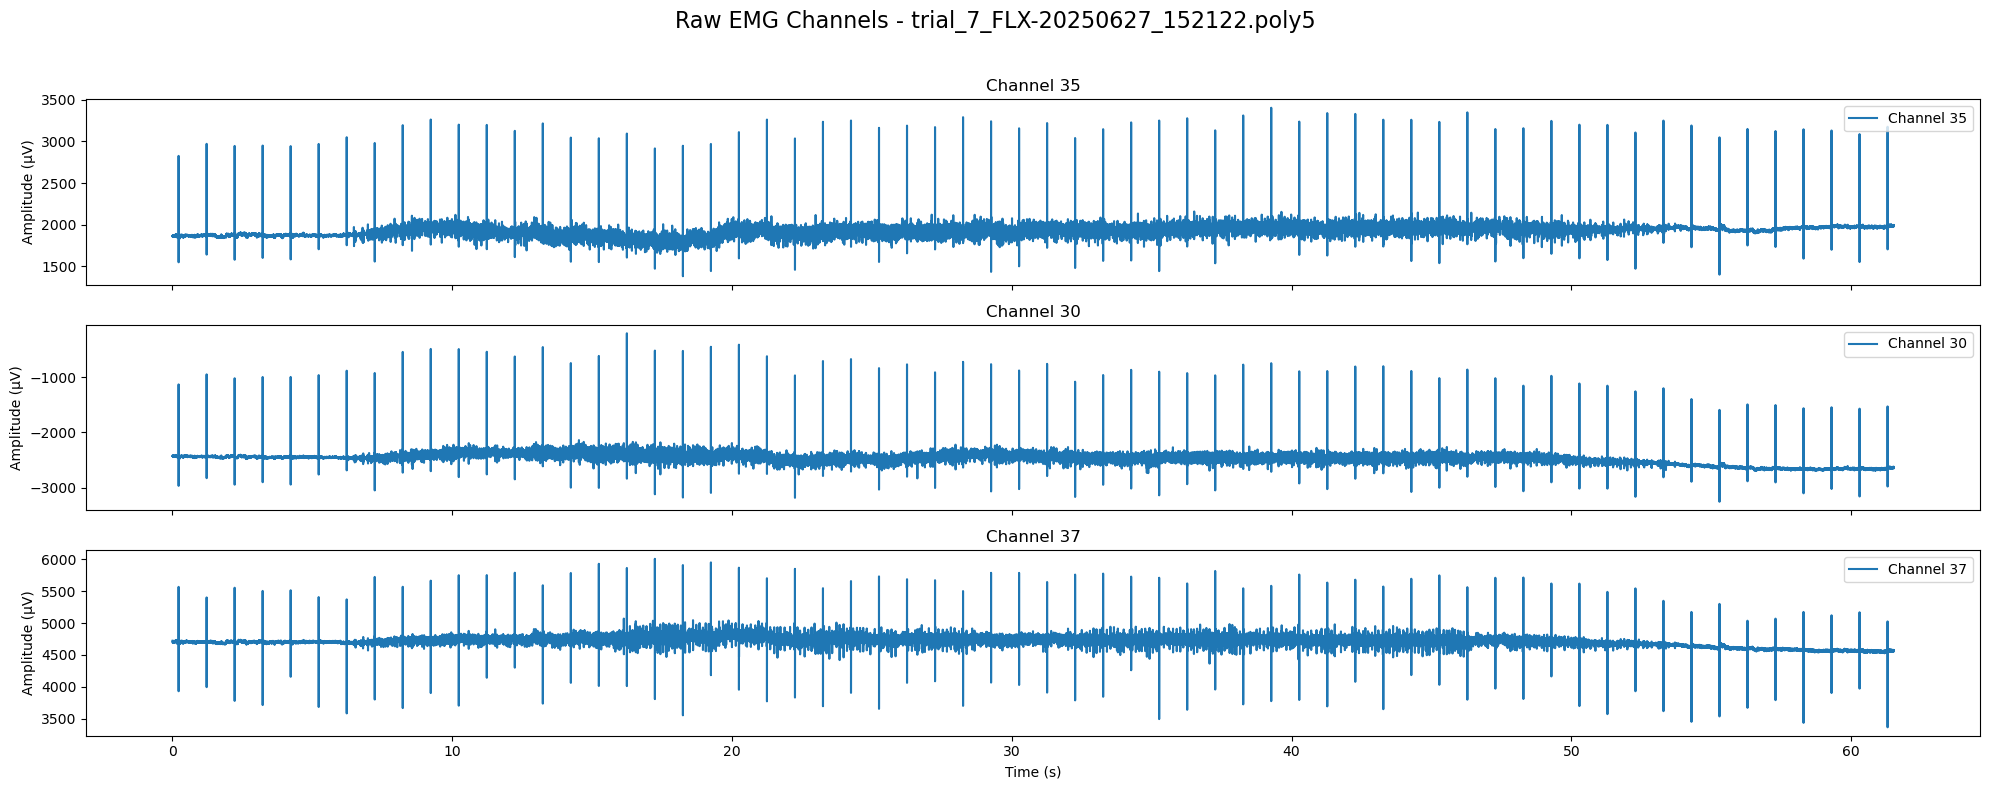

Reading file  G:/My Drive/Research/Data/electrostim_data/Doug 6-27/20250627/trial_8_FLX-20250627_152242.poly5
	 Number of samples:  126210 
	 Number of channels:  76 
	 Sample rate: 2000 Hz
Done reading data.


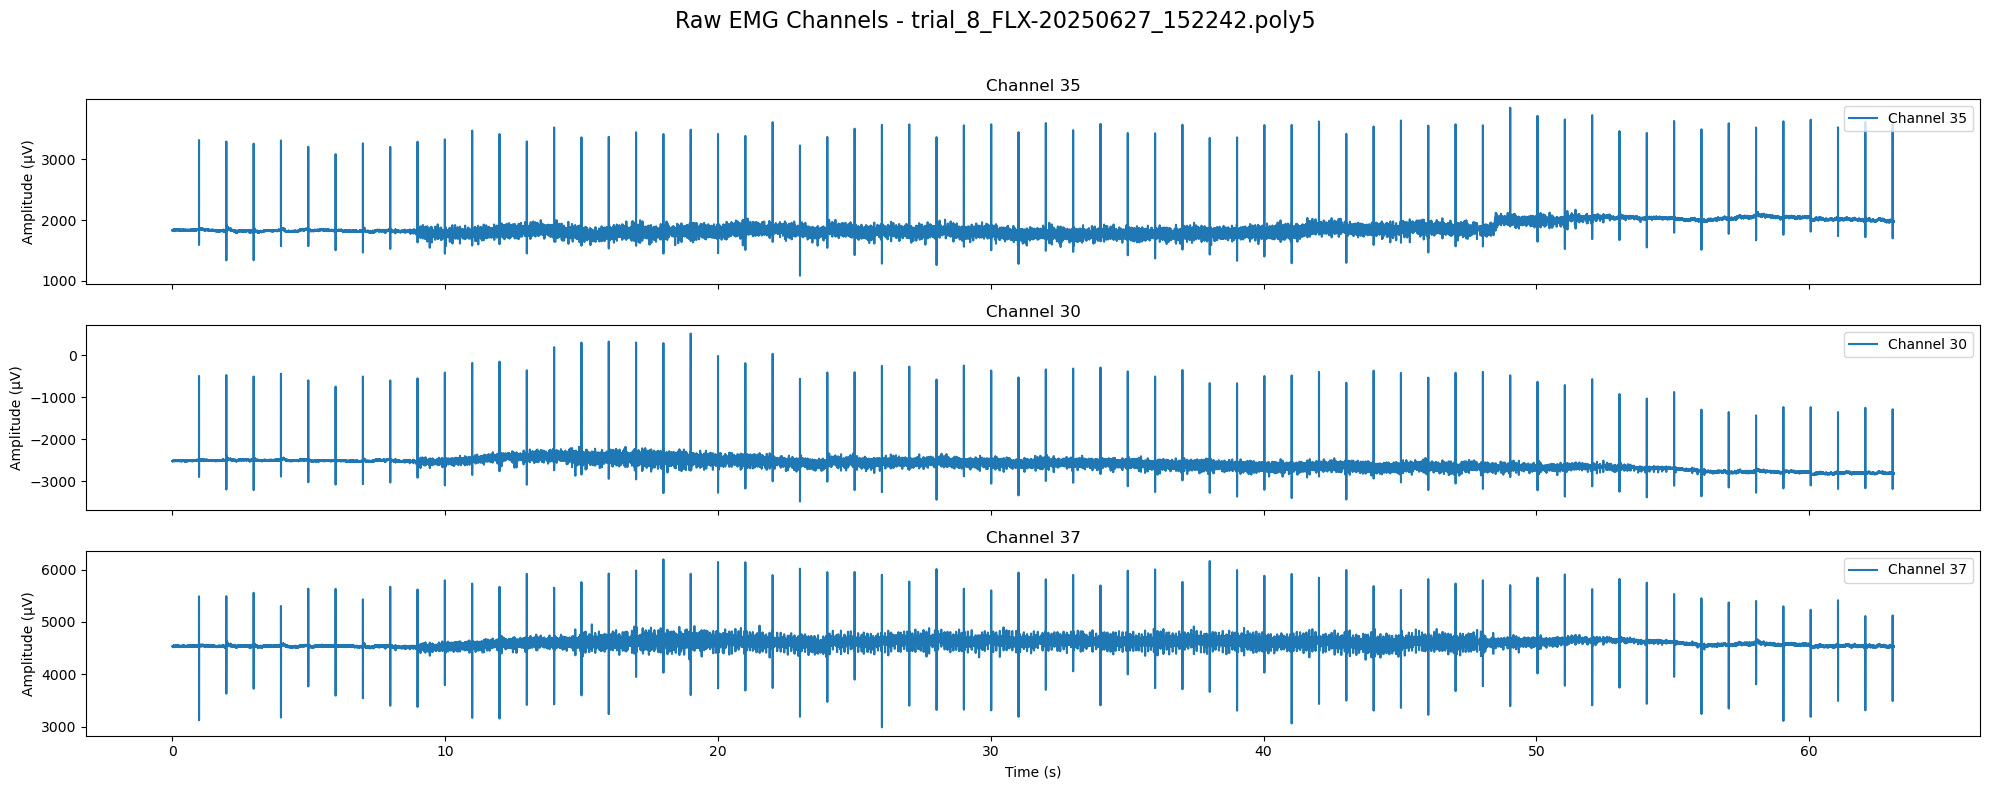

Reading file  G:/My Drive/Research/Data/electrostim_data/Doug 6-27/20250627/trial_19_FLX-20250627_154228.poly5
	 Number of samples:  122430 
	 Number of channels:  76 
	 Sample rate: 2000 Hz
Done reading data.


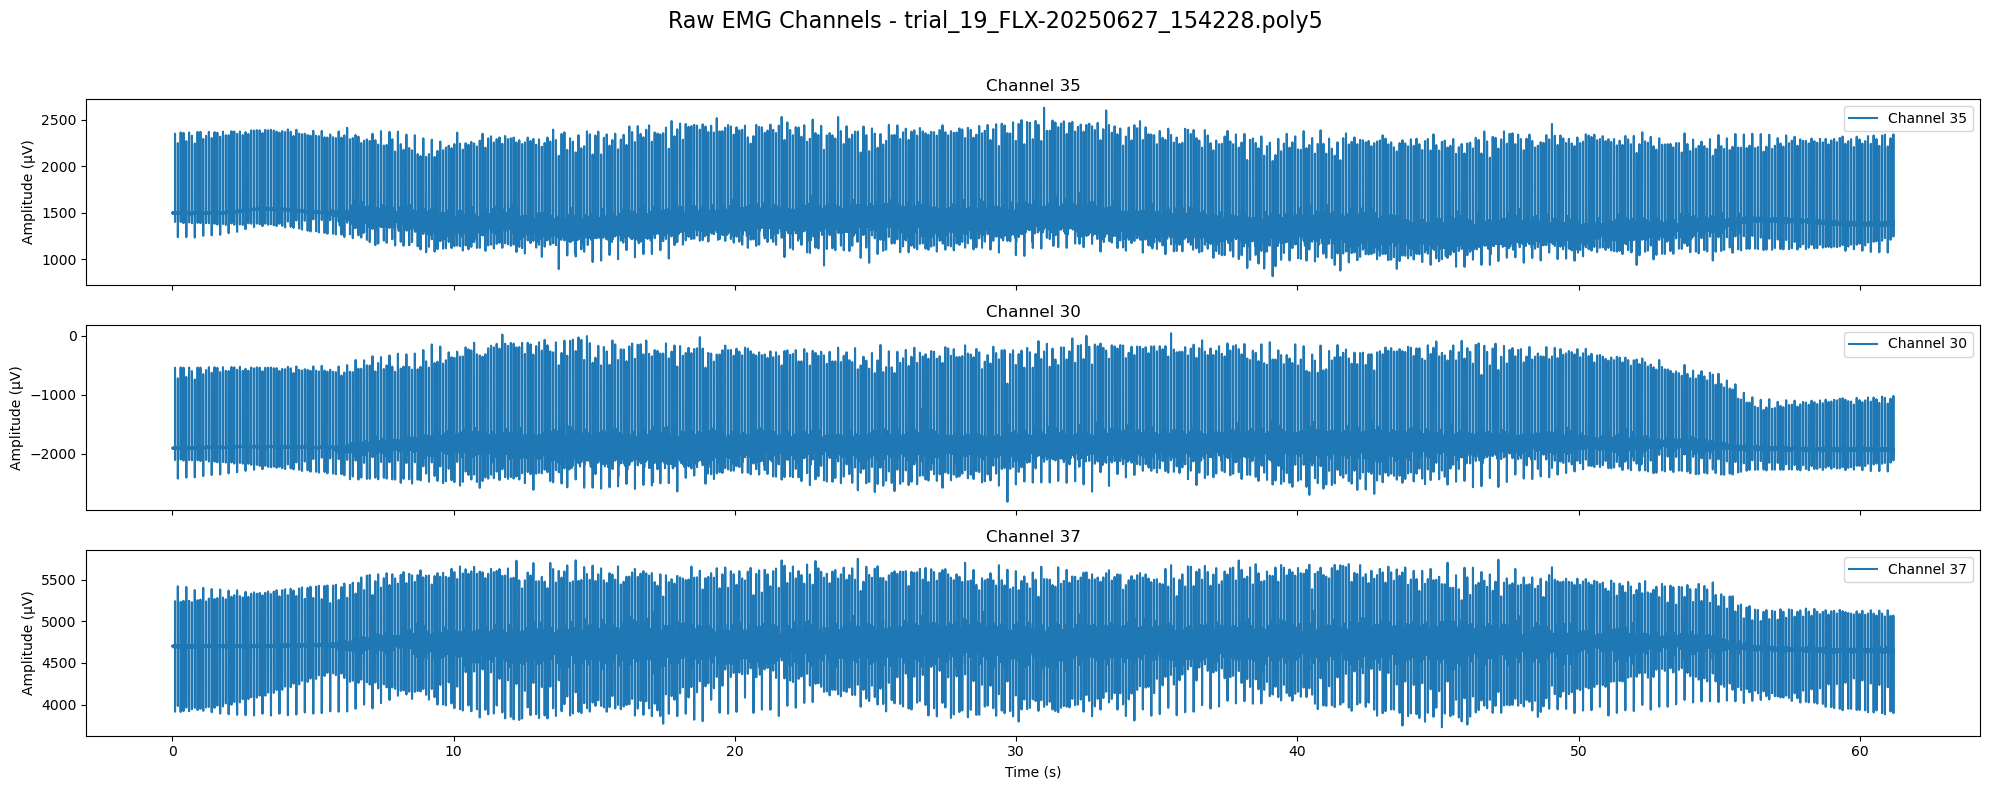

In [43]:
selected_channels = [35, 30, 37]  # Replace with the exact indices you want

for file_path in flexion_files:
    reader = Poly5Reader(file_path)
    samples = reader.samples
    ch_names = reader.ch_names
    sample_rate = reader.sample_rate

    # Extract EMG and time axis
    trigger = samples[73,:]
    emg = samples[1:65, :]
    time_axis = np.arange(emg.shape[1]) / sample_rate

    # Plot for this file
    num_selected = len(selected_channels)
    fig, axes = plt.subplots(num_selected, 1, sharex=True, figsize=(20, 8))
    plt.subplots_adjust(hspace=0.5)

    for ax, ch_idx in zip(axes, selected_channels):
        ax.plot(time_axis, emg[ch_idx], label=f"Channel {ch_idx}")
        ax.set_ylabel("Amplitude (µV)")
        ax.legend(loc="upper right")
        ax.set_title(f"Channel {ch_idx}")  # Add title for each subplot

    axes[-1].set_xlabel("Time (s)")
    fig.suptitle(f"Raw EMG Channels - {os.path.basename(file_path)}", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

In [44]:
def bandpass_filter(x, lowcut, highcut, fs, order=4):
    nyq = fs/2
    b,a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, x)

def lpf_smooth(sig, cutoff, fs, order=5):
    nyq = fs/2
    b,a = butter(order, cutoff/nyq, btype='low')
    if sig.ndim==1:
        return filtfilt(b,a,sig)
    else:
        return np.vstack([filtfilt(b,a,chan) for chan in sig])
fs          = 2000.0        # sampling rate
lowcut      = 20.0          # band-pass low end (Hz)
highcut     = 150.0         # band-pass high end (Hz)
bp_order    = 4

lpf_cutoff  = 10.0          # envelope smoothing cutoff (Hz)
lpf_order   = 4

Reading file  G:/My Drive/Research/Data/electrostim_data/Doug 6-27/20250627/trial_6_FLX-20250627_151916.poly5
	 Number of samples:  122430 
	 Number of channels:  76 
	 Sample rate: 2000 Hz
Done reading data.


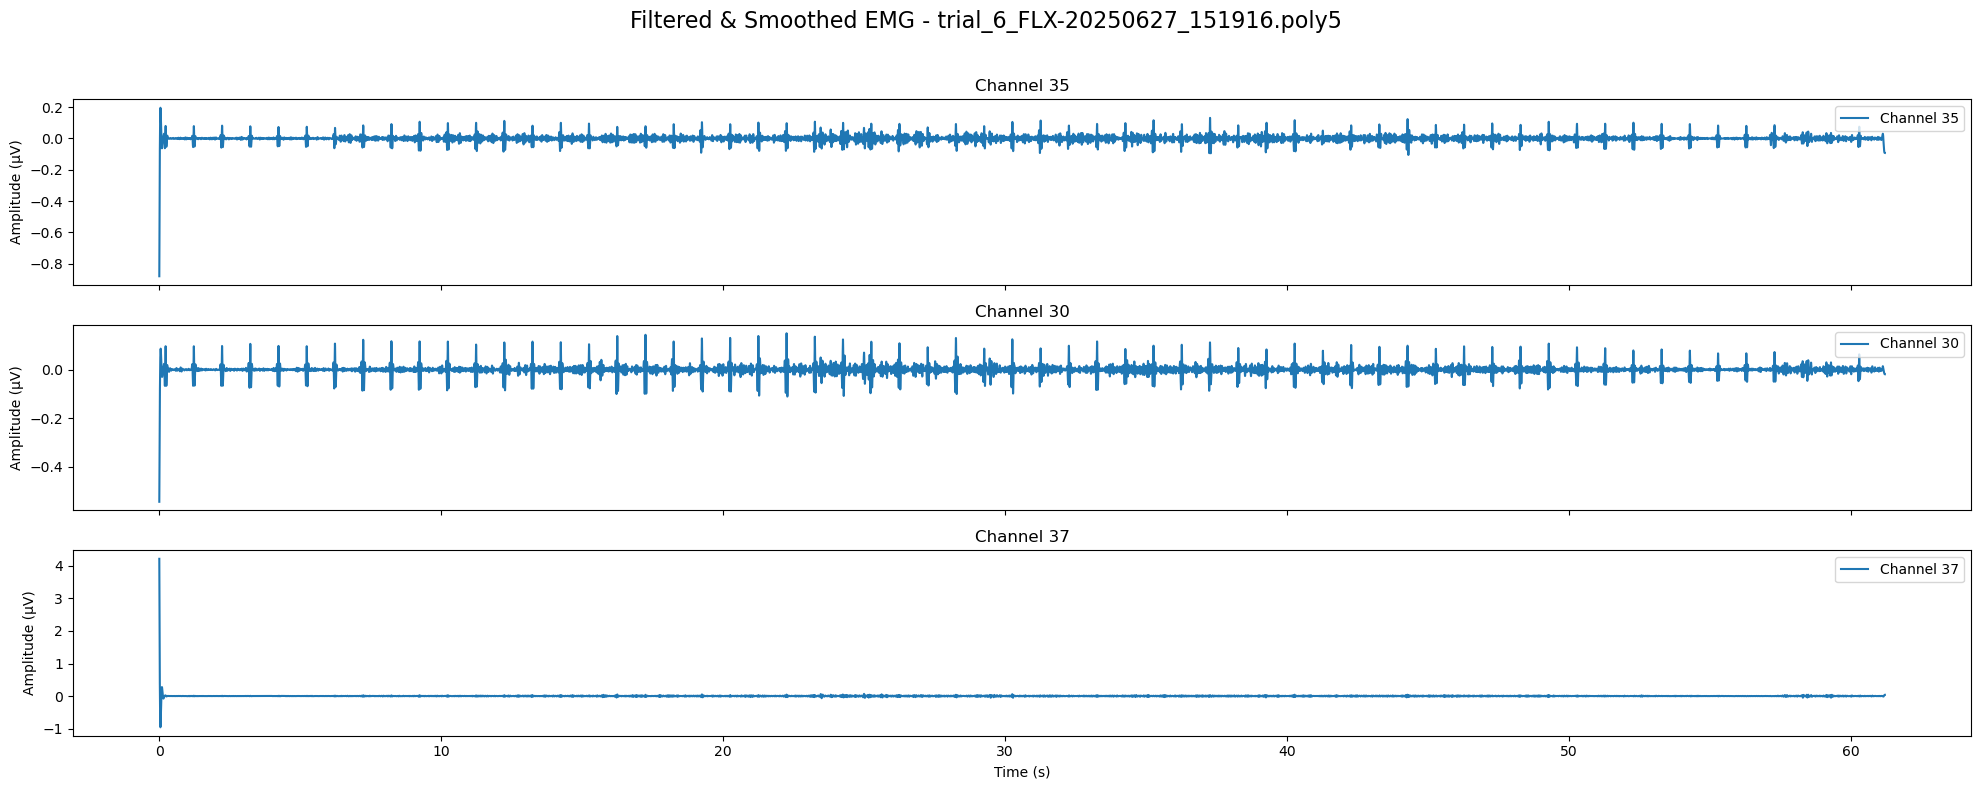

Reading file  G:/My Drive/Research/Data/electrostim_data/Doug 6-27/20250627/trial_7_FLX-20250627_152122.poly5
	 Number of samples:  123060 
	 Number of channels:  76 
	 Sample rate: 2000 Hz
Done reading data.


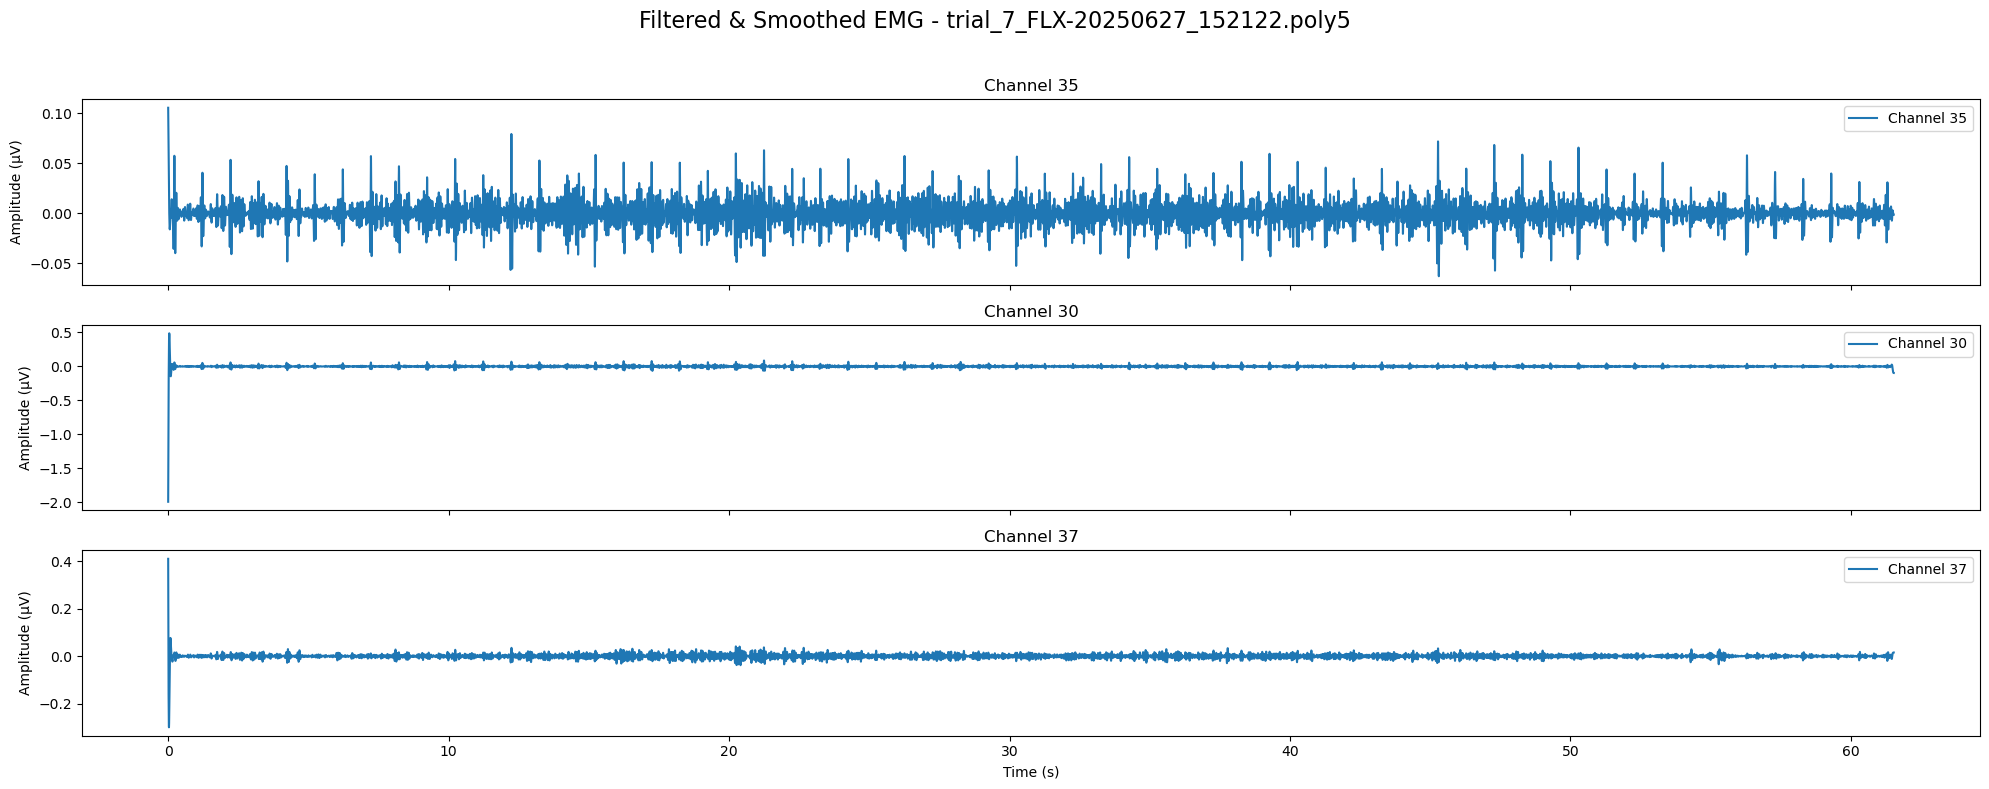

Reading file  G:/My Drive/Research/Data/electrostim_data/Doug 6-27/20250627/trial_8_FLX-20250627_152242.poly5
	 Number of samples:  126210 
	 Number of channels:  76 
	 Sample rate: 2000 Hz
Done reading data.


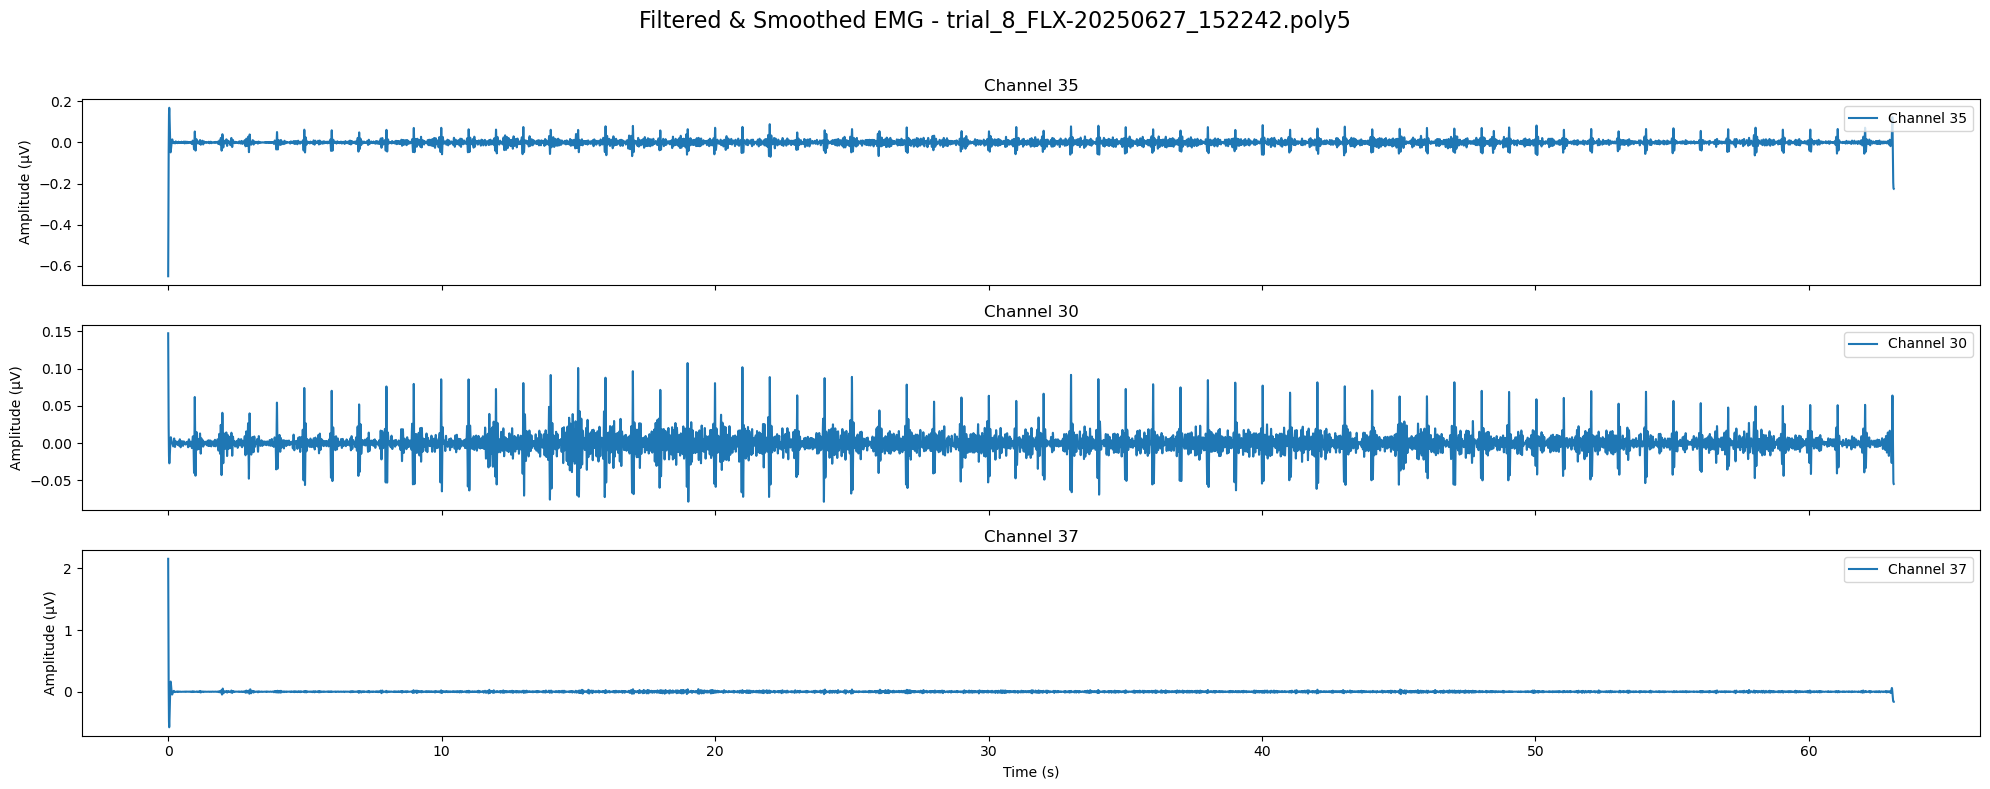

Reading file  G:/My Drive/Research/Data/electrostim_data/Doug 6-27/20250627/trial_19_FLX-20250627_154228.poly5
	 Number of samples:  122430 
	 Number of channels:  76 
	 Sample rate: 2000 Hz
Done reading data.


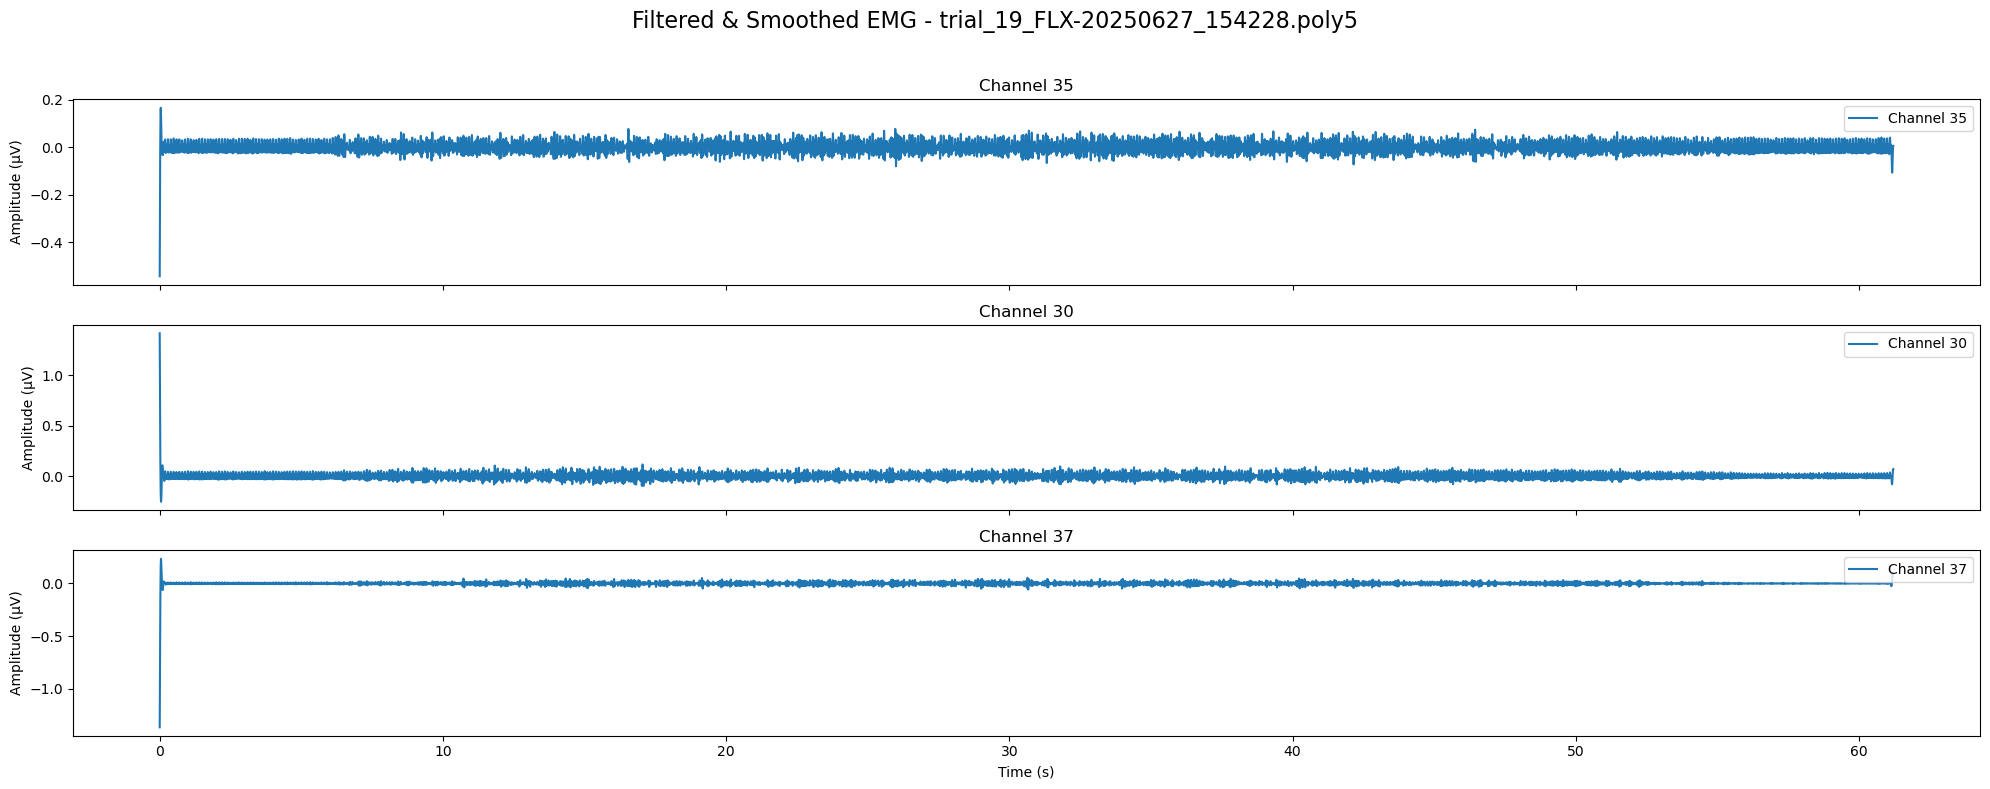

In [45]:
selected_channels = [35, 30, 37]  # Replace with the exact indices you want

for file_path in flexion_files:
    reader = Poly5Reader(file_path)
    samples = reader.samples
    sample_rate = reader.sample_rate
    emg = samples[1:65, :]
    time_axis = np.arange(emg.shape[1]) / sample_rate

    # --- Bandpass filter all EMG channels ---
    filtered = np.zeros_like(emg)
    for ch in range(emg.shape[0]):
        filtered[ch, :] = bandpass_filter(emg[ch, :], lowcut, highcut, sample_rate, bp_order)

    # --- Low-pass smooth all EMG channels ---
    smoothed = lpf_smooth(filtered, lpf_cutoff, sample_rate, lpf_order)

    # --- Plot for selected channels ---
    num_selected = len(selected_channels)
    fig, axes = plt.subplots(num_selected, 1, sharex=True, figsize=(20, 8))
    plt.subplots_adjust(hspace=0.5)

    for ax, ch_idx in zip(axes, selected_channels):
        ax.plot(time_axis, smoothed[ch_idx], label=f"Channel {ch_idx}")
        ax.set_ylabel("Amplitude (µV)")
        ax.legend(loc="upper right")
        ax.set_title(f"Channel {ch_idx}")

    axes[-1].set_xlabel("Time (s)")
    fig.suptitle(f"Filtered & Smoothed EMG - {os.path.basename(file_path)}", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

Reading file  G:/My Drive/Research/Data/electrostim_data/Doug 6-27/20250627/trial_6_FLX-20250627_151916.poly5
	 Number of samples:  122430 
	 Number of channels:  76 
	 Sample rate: 2000 Hz
Done reading data.


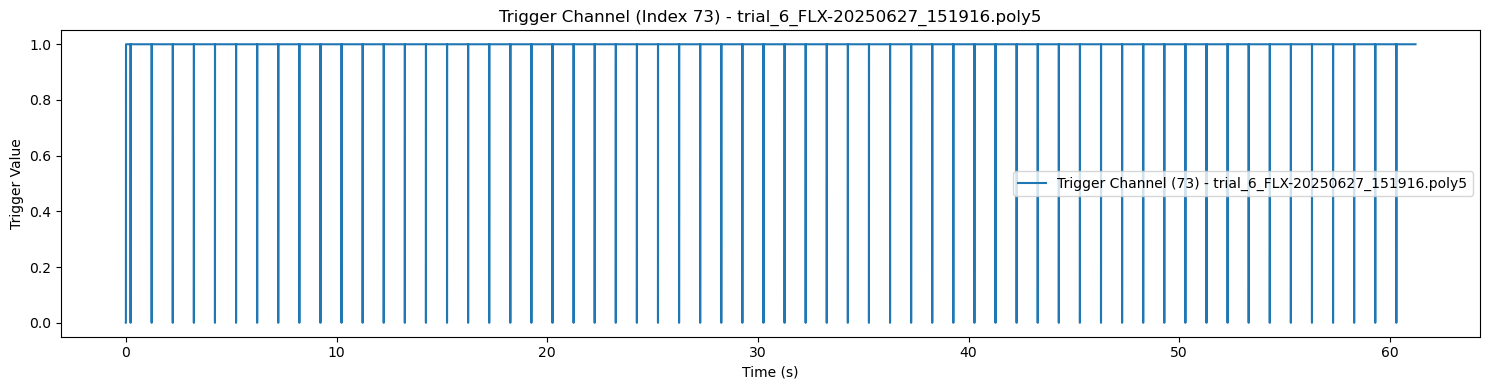

Reading file  G:/My Drive/Research/Data/electrostim_data/Doug 6-27/20250627/trial_7_FLX-20250627_152122.poly5
	 Number of samples:  123060 
	 Number of channels:  76 
	 Sample rate: 2000 Hz
Done reading data.


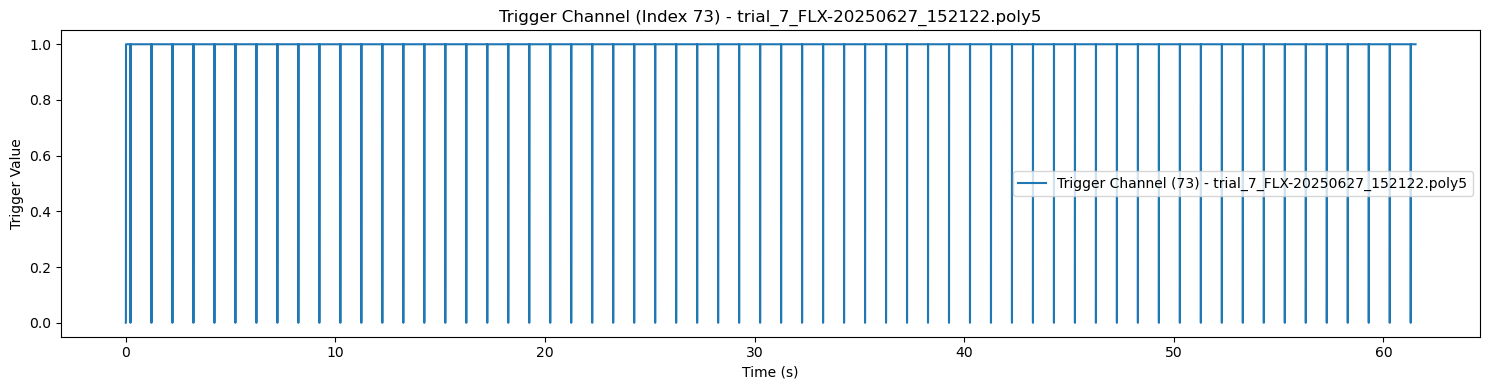

Reading file  G:/My Drive/Research/Data/electrostim_data/Doug 6-27/20250627/trial_8_FLX-20250627_152242.poly5
	 Number of samples:  126210 
	 Number of channels:  76 
	 Sample rate: 2000 Hz
Done reading data.


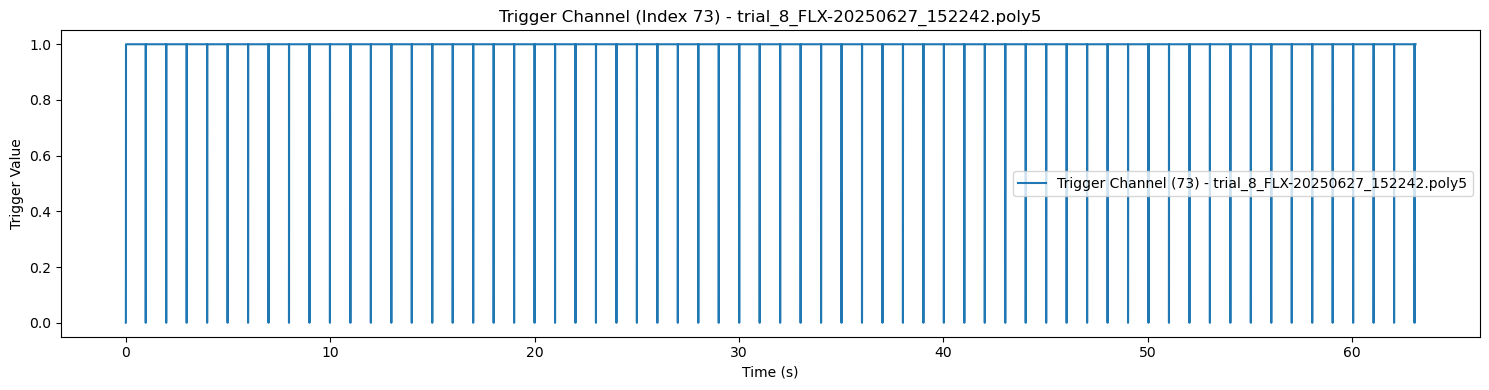

Reading file  G:/My Drive/Research/Data/electrostim_data/Doug 6-27/20250627/trial_19_FLX-20250627_154228.poly5
	 Number of samples:  122430 
	 Number of channels:  76 
	 Sample rate: 2000 Hz
Done reading data.


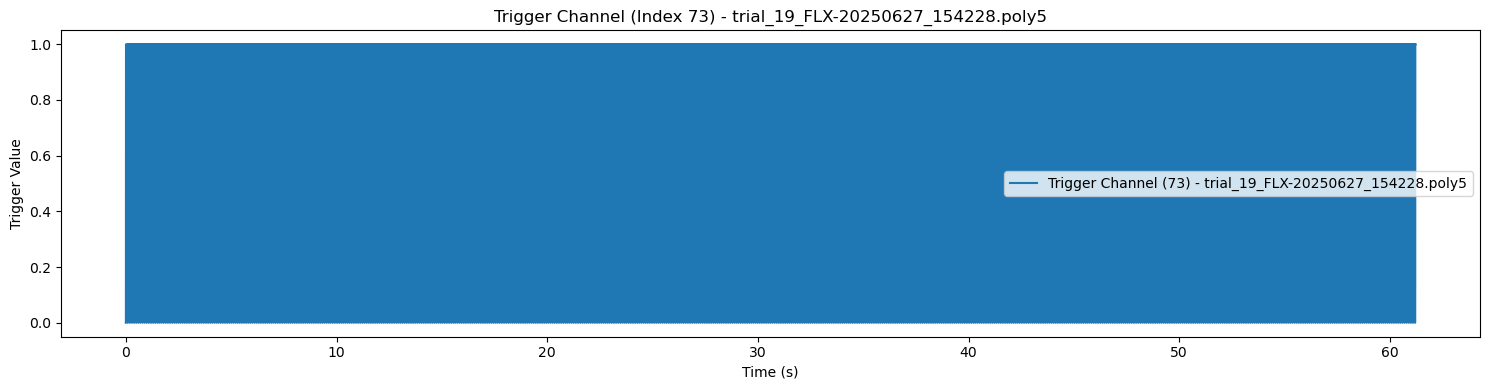

In [46]:
# Plot the trigger channel for all selected flexion files
for file_path in flexion_files:
    reader = Poly5Reader(file_path)
    samples = reader.samples
    sample_rate = reader.sample_rate
    time_axis = np.arange(samples.shape[1]) / sample_rate
    trigger = samples[73, :]

    plt.figure(figsize=(15, 4))
    plt.plot(time_axis, trigger, label=f"Trigger Channel (73) - {os.path.basename(file_path)}")
    plt.xlabel("Time (s)")
    plt.ylabel("Trigger Value")
    plt.title(f"Trigger Channel (Index 73) - {os.path.basename(file_path)}")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [47]:
# Find falling edges for all selected flexion files
for file_path in flexion_files:
    reader = Poly5Reader(file_path)
    samples = reader.samples
    sample_rate = reader.sample_rate
    time_axis = np.arange(samples.shape[1]) / sample_rate
    trigger = samples[73, :]

    # Find falling edges
    falling_edges = np.where(np.diff(trigger) < -0.5)[0] + 1  # +1 to get the index after the transition
    print(f"\nFile: {os.path.basename(file_path)}")
    print("Indices where trigger goes from 1 to 0:", falling_edges)

    # Time between each trigger (in seconds)
    falling_times = time_axis[falling_edges]
    intervals = np.diff(falling_times)
    print("Time between each trigger (s):", intervals)

Reading file  G:/My Drive/Research/Data/electrostim_data/Doug 6-27/20250627/trial_6_FLX-20250627_151916.poly5
	 Number of samples:  122430 
	 Number of channels:  76 
	 Sample rate: 2000 Hz
Done reading data.

File: trial_6_FLX-20250627_151916.poly5
Indices where trigger goes from 1 to 0: [   446   2448   4451   6454   8456  10459  12462  14464  16467  18470
  20473  22476  24478  26481  28484  30487  32489  34492  36495  38497
  40500  42503  44505  46508  48511  50514  52517  54519  56522  58525
  60528  62530  64533  66536  68538  70541  72544  74546  76549  78552
  80555  82558  84560  86563  88566  90568  92571  94574  96577  98579
 100582 102585 104587 106590 108593 110595 112599 114601 116604 118607
 120609]
Time between each trigger (s): [1.001  1.0015 1.0015 1.001  1.0015 1.0015 1.001  1.0015 1.0015 1.0015
 1.0015 1.001  1.0015 1.0015 1.0015 1.001  1.0015 1.0015 1.001  1.0015
 1.0015 1.001  1.0015 1.0015 1.0015 1.0015 1.001  1.0015 1.0015 1.0015
 1.001  1.0015 1.0015 1.001  1.

Reading file  G:/My Drive/Research/Data/electrostim_data/Doug 6-27/20250627/trial_6_FLX-20250627_151916.poly5
	 Number of samples:  122430 
	 Number of channels:  76 
	 Sample rate: 2000 Hz
Done reading data.
Reading file  G:/My Drive/Research/Data/electrostim_data/Doug 6-27/20250627/trial_7_FLX-20250627_152122.poly5
	 Number of samples:  123060 
	 Number of channels:  76 
	 Sample rate: 2000 Hz
Done reading data.
Reading file  G:/My Drive/Research/Data/electrostim_data/Doug 6-27/20250627/trial_8_FLX-20250627_152242.poly5
	 Number of samples:  126210 
	 Number of channels:  76 
	 Sample rate: 2000 Hz
Done reading data.
Reading file  G:/My Drive/Research/Data/electrostim_data/Doug 6-27/20250627/trial_19_FLX-20250627_154228.poly5
	 Number of samples:  122430 
	 Number of channels:  76 
	 Sample rate: 2000 Hz
Done reading data.


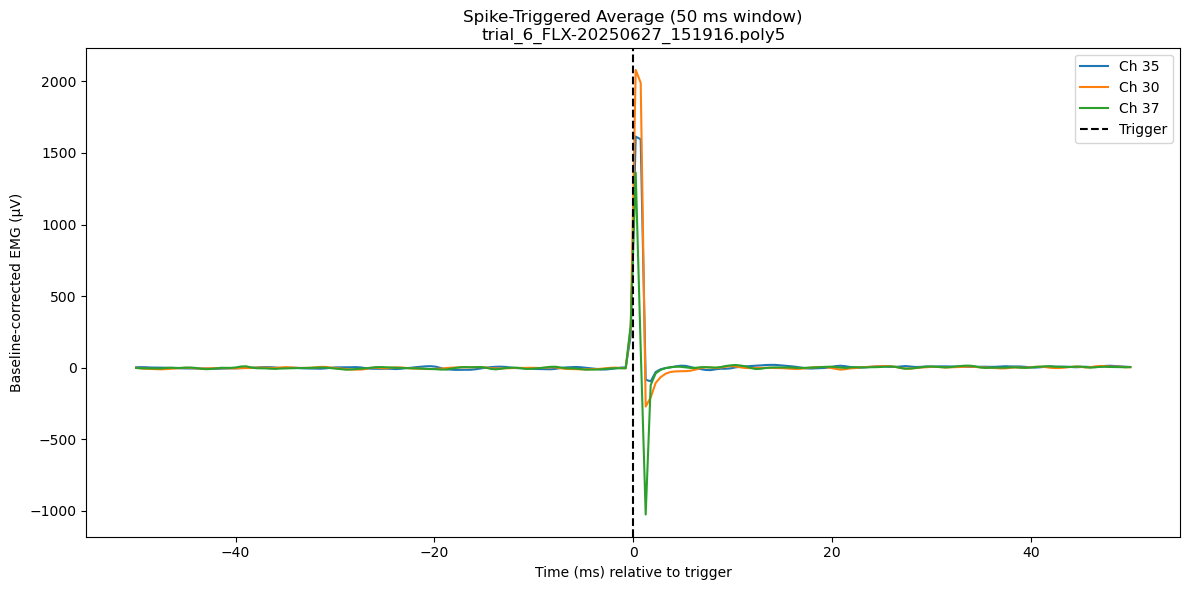

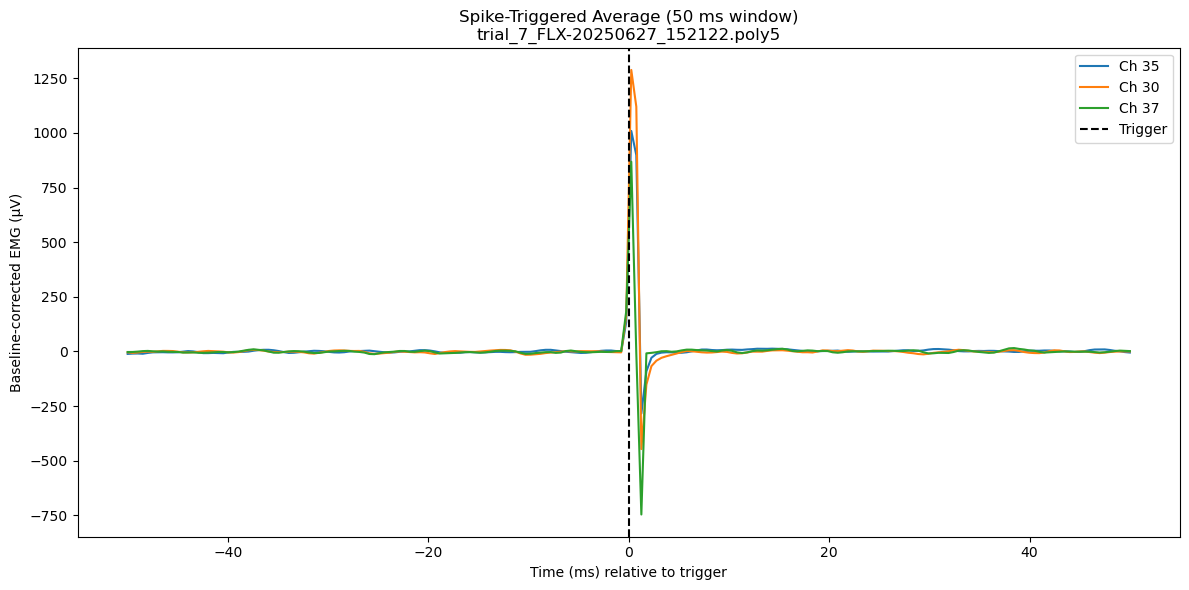

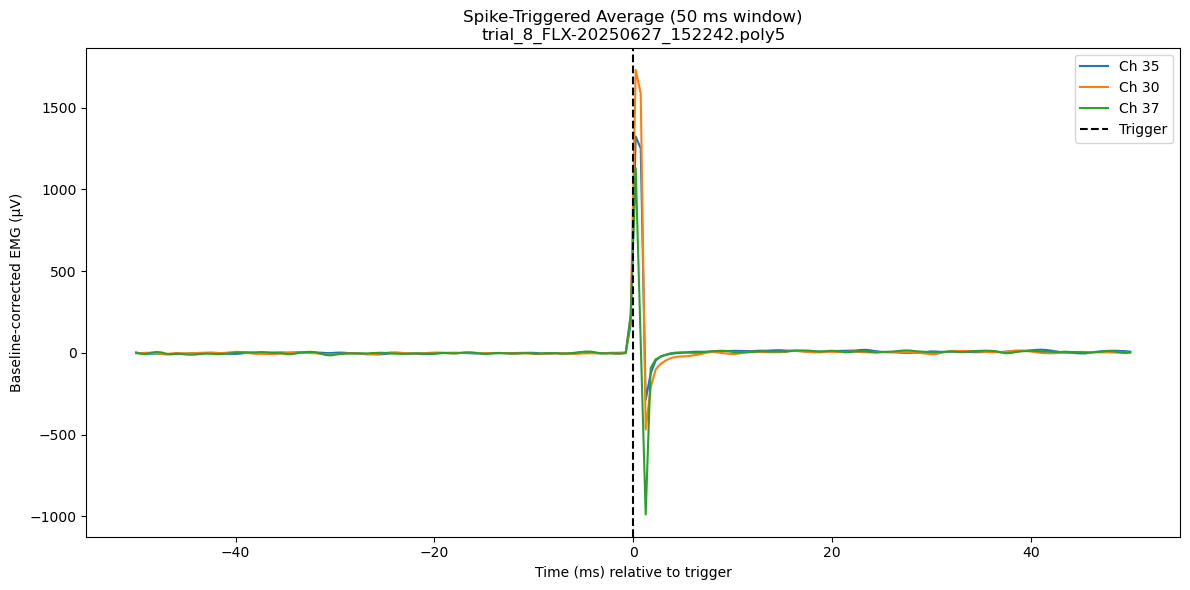

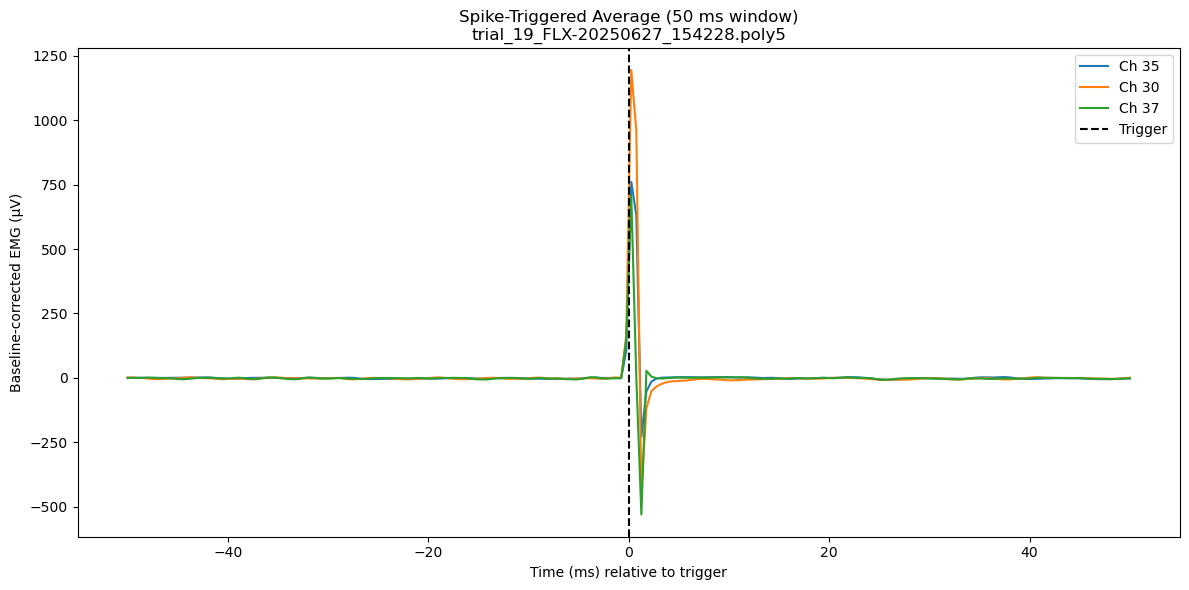

In [48]:
# Spike-Triggered Average (STA) with Baseline Correction (±50 ms window) for all flexion_files

window_ms = 50  # window before and after trigger in ms

selected_channels = [35, 30, 37]  # or any channels you want

for file_path in flexion_files:
    reader = Poly5Reader(file_path)
    samples = reader.samples
    sample_rate = reader.sample_rate
    emg = samples[1:65, :]
    trigger = samples[73, :]
    time_axis = np.arange(emg.shape[1]) / sample_rate

    window_samples = int(window_ms * sample_rate / 1000)  # samples per side
    total_window = 2 * window_samples  # total window size (samples)

    # Find trigger events (rising edges)
    trigger_diff = np.diff(trigger)
    trigger_onsets = np.where(trigger_diff > 0.5)[0] + 1  # adjust for diff offset

    # Only keep triggers far enough from start/end for window
    valid_triggers = trigger_onsets[
        (trigger_onsets > window_samples) & (trigger_onsets < trigger.shape[0] - window_samples)
    ]

    # Extract and baseline-correct EMG snippets around each trigger
    snippets = []
    for idx in valid_triggers:
        snippet = emg[:, idx - window_samples : idx + window_samples]
        baseline = np.mean(snippet[:, :window_samples], axis=1, keepdims=True)
        snippet_corrected = snippet - baseline
        snippets.append(snippet_corrected)

    if len(snippets) == 0:
        print(f"No valid triggers found in {os.path.basename(file_path)}")
        continue

    snippets = np.stack(snippets, axis=0)  # shape: (n_triggers, n_channels, window)

    # Compute average across baseline-corrected snippets
    sta = np.mean(snippets, axis=0)  # shape: (n_channels, window)

    # Time axis for window (centered at trigger)
    sta_time = np.linspace(-window_ms, window_ms, total_window)

    # Plot STA for selected channels
    plt.figure(figsize=(12, 6))
    for ch in selected_channels:
        plt.plot(sta_time, sta[ch], label=f'Ch {ch}')
    plt.axvline(0, color='k', linestyle='--', label='Trigger')
    plt.xlabel('Time (ms) relative to trigger')
    plt.ylabel('Baseline-corrected EMG (µV)')
    plt.title(f'Spike-Triggered Average (50 ms window)\n{os.path.basename(file_path)}')
    plt.legend()
    plt.tight_layout()


In [49]:
# Compute peak-to-peak amplitude for each channel in the STA for all flexion_files

window_ms = 50  # window before and after trigger in ms
selected_channels = [35, 30, 37]  # or any channels you want
all_peak_to_peak = {}
for file_path in flexion_files:
    # Only redefine reader and samples, as flexion_files is already defined
    reader = Poly5Reader(file_path)
    samples = reader.samples
    sample_rate = reader.sample_rate  # If you want to use the sample rate from the file, otherwise use your global fs

    emg = samples[1:65, :]
    trigger = samples[73, :]
    window_samples = int(window_ms * sample_rate / 1000)
    total_window = 2 * window_samples

    # Find trigger events (rising edges)
    trigger_diff = np.diff(trigger)
    trigger_onsets = np.where(trigger_diff > 0.5)[0] + 1

    # Only keep triggers far enough from start/end for window
    valid_triggers = trigger_onsets[
        (trigger_onsets > window_samples) & (trigger_onsets < trigger.shape[0] - window_samples)
    ]

    # Extract and baseline-correct EMG snippets around each trigger
    snippets = []
    for idx in valid_triggers:
        snippet = emg[:, idx - window_samples : idx + window_samples]
        baseline = np.mean(snippet[:, :window_samples], axis=1, keepdims=True)
        snippet_corrected = snippet - baseline
        snippets.append(snippet_corrected)

    if len(snippets) == 0:
        print(f"No valid triggers found in {os.path.basename(file_path)}")
        continue

    snippets = np.stack(snippets, axis=0)  # shape: (n_triggers, n_channels, window)
    sta = np.mean(snippets, axis=0)  # shape: (n_channels, window)

    # Compute peak-to-peak amplitude for each channel in the STA
    peak_to_peak = np.ptp(sta, axis=1)  # shape: (n_channels,)
    all_peak_to_peak[os.path.basename(file_path)] = peak_to_peak

    # Print results for selected channels
    print(f"\nFile: {os.path.basename(file_path)}")
    for ch in selected_channels:
        print(f"  Channel {ch}: Peak-to-peak amplitude = {peak_to_peak[ch]:.2f} µV")

Reading file  G:/My Drive/Research/Data/electrostim_data/Doug 6-27/20250627/trial_6_FLX-20250627_151916.poly5
	 Number of samples:  122430 
	 Number of channels:  76 
	 Sample rate: 2000 Hz
Done reading data.

File: trial_6_FLX-20250627_151916.poly5
  Channel 35: Peak-to-peak amplitude = 1709.31 µV
  Channel 30: Peak-to-peak amplitude = 2350.67 µV
  Channel 37: Peak-to-peak amplitude = 2387.54 µV
Reading file  G:/My Drive/Research/Data/electrostim_data/Doug 6-27/20250627/trial_7_FLX-20250627_152122.poly5
	 Number of samples:  123060 
	 Number of channels:  76 
	 Sample rate: 2000 Hz
Done reading data.

File: trial_7_FLX-20250627_152122.poly5
  Channel 35: Peak-to-peak amplitude = 1293.36 µV
  Channel 30: Peak-to-peak amplitude = 1735.00 µV
  Channel 37: Peak-to-peak amplitude = 1614.48 µV
Reading file  G:/My Drive/Research/Data/electrostim_data/Doug 6-27/20250627/trial_8_FLX-20250627_152242.poly5
	 Number of samples:  126210 
	 Number of channels:  76 
	 Sample rate: 2000 Hz
Done readi

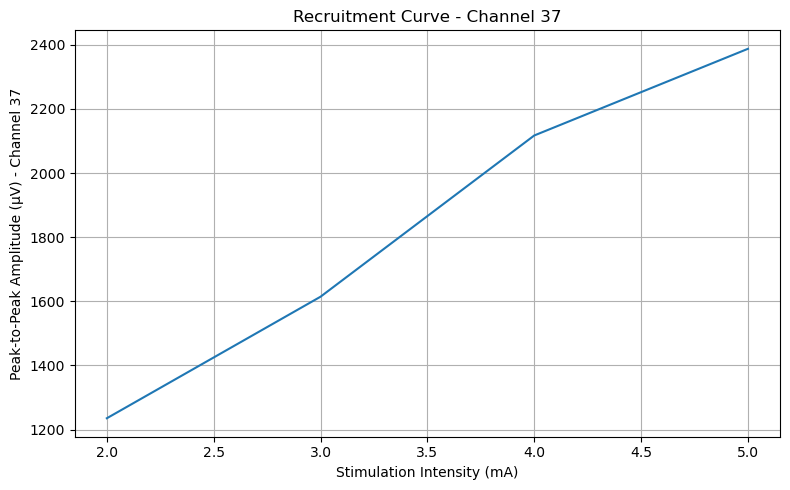

In [ ]:


stim_intensity_dict = {
    'trial_6_FLX-20250627_151916.poly5': 5,
    'trial_7_FLX-20250627_152122.poly5': 3,
    'trial_8_FLX-20250627_152242.poly5': 4,
    'trial_19_FLX-20250627_154228.poly5': 2
    # Add more/change as needed
}

channel_to_plot = 37  # Choose the channel for the recruitment curve

intensities = []
amplitudes = []

for fname, peak_to_peak in all_peak_to_peak.items():
    if fname in stim_intensity_dict:
        intensities.append(stim_intensity_dict[fname])
        amplitudes.append(peak_to_peak[channel_to_plot])

# Sort by intensity 
if intensities:
    sorted_pairs = sorted(zip(intensities, amplitudes))
    sorted_intensities, sorted_amplitudes = zip(*sorted_pairs)

    plt.figure(figsize=(8, 5))
    plt.plot(sorted_intensities, sorted_amplitudes)
    plt.xlabel('Stimulation Intensity (mA)')
    plt.ylabel(f'Peak-to-Peak Amplitude (µV) - Channel {channel_to_plot}')
    plt.title('Recruitment Curve - Channel {}'.format(channel_to_plot))
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("No matching trials found between all_peak_to_peak and stim_intensity_dict. 😦")